# Transformações Afins

**Objetivo: ao fim desta atividade, o aluno deverá ser capaz de construir transformações lineares afins para gerar efeitos geométricos conhecidos.**

Instruções:

* Faça essa atividade em duplas ou trios. Use a lousa, caderno, etc.
* O tempo total da atividade é de 1h30
* Entregue os exercício resolvidos em papel manuscrito (sulfite ou almaço), indicando o nome de todos os integrantes do grupo
* Ao fim da atividade, teremos um teste (individual) sobre a atividade
* A etapa "grupo" receberá nota entre 0 e 1. A etapa "individual" receberá nota entre 0 e 1. A nota final é a média geométrica entre as duas.


Sobre esta atividade e estudo prévio

Nesta atividade, estamos falando de *transformações afins* (*affine transforms*). 

## Exercício 1

Vamos partir de uma núvem de pontos $X \in \mathbb{R}^{2 \times n}$. Gostaríamos de gerar uma outra núvem $Y \in \mathbb{R}^{2 \times n}$ usando uma matriz $A \in \mathbb{R}^{2 \times 2}$ através da equação:

$$
Y = AX
$$

Nessas condições, dizemos que $A$ representa uma *transformação linear* aplicada sobre $X$. Podemos simular essa situação usando:

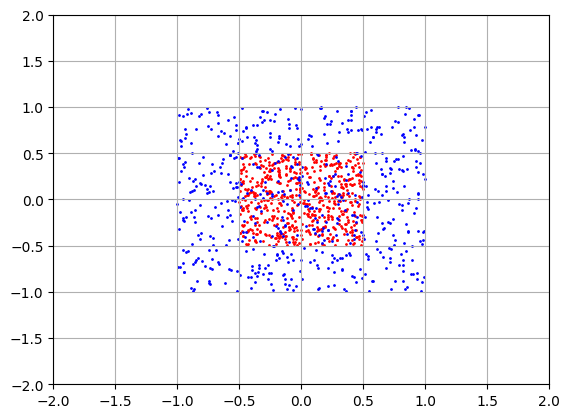

In [3]:
import numpy as np 
import matplotlib.pyplot as plt 

x = np.random.uniform(-0.5, 0.5, size=(2, 600))
A = np.array([ [2, 0], [0, 2] ])
y = A @ x
plt.figure()
plt.scatter(x[0,:], x[1,:], s=1, c='r')
plt.scatter(y[0,:], y[1,:], s=1, c='b')
plt.xlim([-2, 2])
plt.ylim([-2, 2])
plt.grid()
plt.show()

Existem algumas transformações que são conhecidas por seus nomes:

* Rotação (girar ao redor da origem)
* Cisalhamento (deslocar um dos eixos na direção do outro exiso)
* Expansão ou contração (no eixo X e/ou no eixo Y)

Usando o código acima como base, identifique as matrizes, dentre as abaixo, que correspondem a rotações, cisalhamentos, expansões ou contrações:

$$
\begin{bmatrix}
    1 & 0\\
    0 & 2
\end{bmatrix}
\begin{bmatrix}
    1 & 1\\
    0 & 1
\end{bmatrix}
\begin{bmatrix}
    1 & 0\\
    1 & 1
\end{bmatrix}
\begin{bmatrix}
    0.86 & -0.5\\
    0.5 & 0.86
\end{bmatrix}
$$



## Exercício 2: contrações e expansões

Uma matriz na forma:

$$
A = \begin{bmatrix} s_1 & 0 \\ 0 & s_2 \end{bmatrix}
$$

pode ser usada para realizar contrações e expansões. Veja que:

$$
\begin{bmatrix} s_1 & 0 \\ 0 & s_2 \end{bmatrix}
\begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = 
\begin{bmatrix} s_1 x_1 \\ s_2 x_2 \end{bmatrix}
$$

Use esse processo para mapear uma núvem de pontos, inicialmente contida em um quadrado, para um retângulo de altura igual à metade do lado do quadrado e área igual à do quadrado. Em sua resposta (na folha separada) mostre a matriz $A$ e esboce os formatos das núvens de pontos (inicial e final).

## Exercício 3: rotações

Agora, deduziremos o conteúdo de uma matriz de rotação. Talvez você precise das [equações de seno e/ou cosseno da soma de arcos](https://brasilescola.uol.com.br/matematica/transformacoes-trigonometricas.htm) para alguns passos.

Neste exercício, trabalharemos com a rotação ao redor da origem. Na rotação, gostaríamos de multiplicar um vetor por uma matriz de forma que o resultado tem o mesmo módulo mas o argumento é somado de $\theta$, ou:

$$
x = r \angle \phi \Rightarrow y = Rx = r \angle (\phi+\theta)
$$


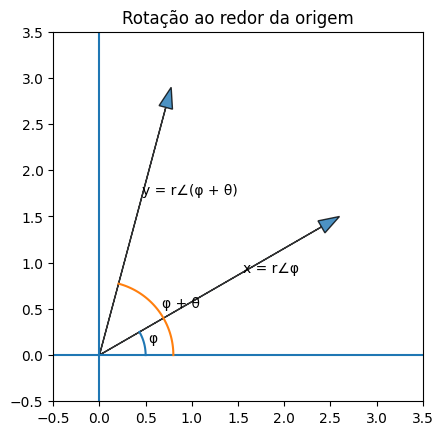

In [13]:
# This script generates a single matplotlib figure illustrating
# a vector x = r∠φ and its rotation y = R x = r∠(φ + θ).

import numpy as np
import matplotlib.pyplot as plt

# Parameters
r = 3
phi = np.deg2rad(30)      # initial angle (φ)
theta = np.deg2rad(45)    # rotation angle (θ)

# Original vector x
x = np.array([r * np.cos(phi), r * np.sin(phi)])

# Rotated vector y
y = np.array([r * np.cos(phi + theta), r * np.sin(phi + theta)])

# Create figure
plt.figure()
plt.axhline(0)
plt.axvline(0)

# Plot vectors as arrows from origin
plt.arrow(0, 0, x[0], x[1], length_includes_head=True, head_width=0.15, alpha=0.8)
plt.arrow(0, 0, y[0], y[1], length_includes_head=True, head_width=0.15, alpha=0.8)

# Draw arc for φ
angle_phi = np.linspace(0, phi, 100)
plt.plot(0.5 * np.cos(angle_phi), 0.5 * np.sin(angle_phi))

# Draw arc for φ + θ
angle_phi_theta = np.linspace(0, phi + theta, 100)
plt.plot(0.8 * np.cos(angle_phi_theta), 0.8 * np.sin(angle_phi_theta))

# Annotations
plt.text(x[0]*0.6, x[1]*0.6, "x = r∠φ")
plt.text(y[0]*0.6, y[1]*0.6, "y = r∠(φ + θ)")
plt.text(0.55*np.cos(phi/2), 0.55*np.sin(phi/2), "φ")
plt.text(0.85*np.cos((phi+theta)/2), 0.85*np.sin((phi+theta)/2), "φ + θ")

# Formatting
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-0.5, 3.5)
plt.ylim(-0.5, 3.5)
plt.title("Rotação ao redor da origem")
plt.show()


Nessa formulação, temos que:

$$
\begin{bmatrix} r \cos{(\phi+\theta)} \\ r \sin{(\phi+\theta)} \end{bmatrix}
= R \begin{bmatrix} r \cos{\phi} \\ r \sin{\phi} \end{bmatrix} 
$$

Mostre que, nessas condições:

$$
R = \begin{bmatrix} \cos {\theta} & \sin {\theta}\\
-\sin {\theta} & \cos {\theta} \end{bmatrix}
$$

## Exercício 4: transformação composta

Partindo de uma núvem de pontos $X$ contida em um quadrado, podemos aplicar uma contração de $0.5$ no eixo horizontal com uma matriz $A$, gerando $Y=AX$. Após, podemos rotacionar a núvem de pontos $Y$ de 45 graus no sentido anti-horário usando uma matriz de rotação $R$, gerando $Z=RY$.

a) Demonstre que $Z = RAX$

b) Demonstrando que a multiplicação de matrizes não é comutativa, esboce a núvem $Z = RAX$ e, após, a núvem $W = ARX$. Use apoio computacional para verificar os dois casos.


# Exercício 5: translações e coordenadas homogêneas

Antes de prosseguir com essa exposição, vamos refletir sobre o que significa uma multiplicação matricial. Neste exemplo:

$$
\begin{bmatrix}
    a & b\\
    c & d
\end{bmatrix}
\begin{bmatrix}
    x \\
    y
\end{bmatrix}
=
\begin{bmatrix}
    p \\
    q
\end{bmatrix}
$$

devemos lembrar que as componentes $p$ e $q$ são calculadas por:

$$
\begin{cases}
\begin{aligned}
  p &= ax + by\\
  q &= cx + dy
\end{aligned}
\end{cases}
$$

Como já vimos, essa operação funciona para a rotação, expansão/compressão e cisalhamento.

Porém, para fazer uma translação, ainda precisamos de *somar* um vetor, isto é:
$$
\begin{bmatrix}
    x \\
    y
\end{bmatrix}
+
\begin{bmatrix}
    \Delta x \\
    \Delta y
\end{bmatrix}
=
\begin{bmatrix}
    p \\
    q
\end{bmatrix}
$$

Então, se quisermos combinar uma translação com uma rotação, a operação que fazemos é:
$$
\begin{bmatrix}
    a & b\\
    c & d
\end{bmatrix}
\begin{bmatrix}
    x \\
    y
\end{bmatrix}
+
\begin{bmatrix}
    \Delta x \\
    \Delta y
\end{bmatrix}
=
\begin{bmatrix}
    p \\
    q
\end{bmatrix}
$$

e isso pode ser escrito na forma de um sistema como:
$$
\begin{cases}
\begin{aligned}
  p &= ax + by + \Delta x\\
  q &= cx + dy + \Delta y
\end{aligned}
\end{cases}
$$

Vamos usar a seguinte ideia: adicionaremos uma dimensão ao nosso vetor de posição. Essa nova dimensão sempre tem valor 1. Essa dimensão só serve para conseguirmos "encaixar" a translação no mesmo esquema matemático, e não é representada quando plotamos nossos vetores. Daí, podemos re-escrever esse sistema como:

$$
\begin{bmatrix}
    a & b & \Delta x\\
    c & d & \Delta y \\
    0 & 0 & 1 \\
\end{bmatrix}
\begin{bmatrix}
    x \\
    y \\
    1
\end{bmatrix}
=
\begin{bmatrix}
    p \\
    q \\
    1
\end{bmatrix}
$$

A *vantagem* dessa abordagem é que agora podemos incorporar translações entre as nossas transformações implementadas por multiplicação matricial. A *desvantagem* é que agora nossas matrizes de transformação, que eram $2 \times 2$, passam a ser $3 \times 3$ e devem ser completadas da seguinte forma:

$$
\begin{bmatrix}
    a & b \\
    c & d  \\
\end{bmatrix}
\Rightarrow
\begin{bmatrix}
    a & b & 0\\
    c & d & 0 \\
    0 & 0 & 1 \\
\end{bmatrix}
$$

Com base nisso, podemos criar nossa núvem de pontos adicionando uma linha de $1$'s, mantendo a compatibilidade da multiplicação matricial, e, ao desenhar os pontos, ignoramos essa dimensão adicional:

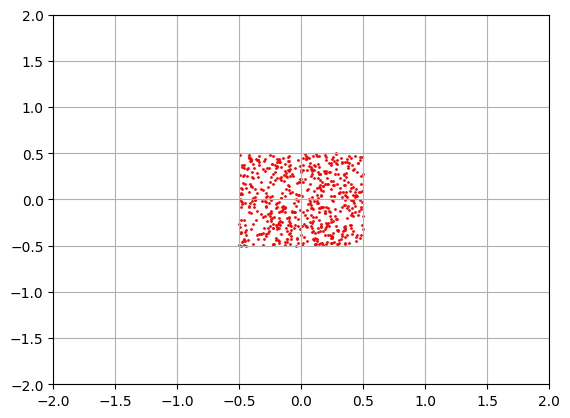

In [4]:
X = np.vstack( (np.random.uniform(-0.5, 0.5, size=(2, 600)), np.ones( (1,600) )))

plt.figure()
plt.scatter(X[0,:], X[1,:], s=1, c='r')
plt.xlim([-2, 2])
plt.ylim([-2, 2])
plt.grid()
plt.show()

Quando adicionamos essa nova dimensão, dizemos que estamos operando em *coordenadas homogêneas*.

!!! info "Pausa para conferir as contas!"
    Verifique que a matrix: $\begin{bmatrix} 0.5 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$ executa uma contração no eixo horizontal.

Encontre as matrizes (em coordenadas homogêneas) para realizar as seguintes operações (se precisar, confira suas respostas implementando código computacional!).

a) uma expansão de 5 vezes no eixo vertical.

b) uma rotação de 30 graus no sentido anti-horário ao redor da origem

c) uma translação de $\begin{bmatrix} 1 \\ -1 \end{bmatrix}$

## Exercício 6: rotações ao redor de pontos arbitrários

A matriz de rotação $R$ que deduzimos anteriormente realiza a rotação ao redor da origem. Porém, podemos fazer uma rotação ao redor de um ponto arbitrário combinando as seguintes transformações:

1. Transladar o ponto de "centro" da rotação até a origem
2. Realizar a rotação
3. Transladar o centro da rotação até sua posição original

isto é, realizamos uma operação como: $Y = T R T^{-1} X$.

Usando essa estratégia, rotacione a núvem de pontos abaixo ao redor de seu próprio centro de 45 graus usando uma única operação $Y = QX$. Em sua resposta, explicite todos os passos que são necessários para gerar a matriz $Q$. Gostaríamos de obter um resultado parecido com:


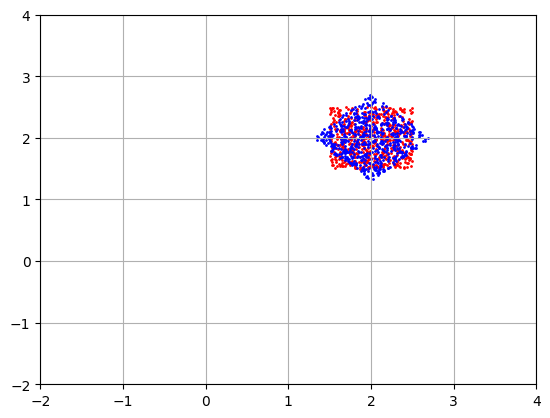

In [16]:
X = np.vstack( (np.random.uniform(1.5, 2.5, size=(2, 600)), np.ones( (1,600) )))
T = np.array( [ [1, 0, -2], [0, 1, -2], [0, 0, 1]])
R = np.array( [[np.sqrt(2)/2, np.sqrt(2)/2, 0], [-np.sqrt(2)/2, np.sqrt(2)/2, 0], [0, 0, 1] ])
Q = np.linalg.inv(T) @ R @ T 
Y = Q @ X
plt.figure()
plt.scatter(X[0,:], X[1,:], s=1, c='r')
plt.scatter(Y[0,:], Y[1,:], s=1, c='b')
plt.xlim([-2, 4])
plt.ylim([-2, 4])
plt.grid()
plt.show()

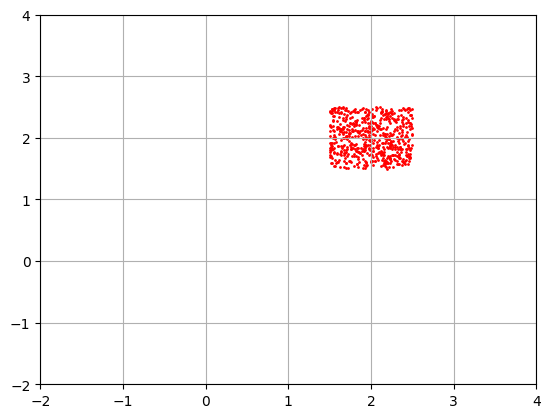

In [6]:
X = np.vstack( (np.random.uniform(1.5, 2.5, size=(2, 600)), np.ones( (1,600) )))

plt.figure()
plt.scatter(X[0,:], X[1,:], s=1, c='r')
plt.xlim([-2, 4])
plt.ylim([-2, 4])
plt.grid()
plt.show()